# 차원 축소 4종 비교 — IRIS 시각화

IRIS 데이터(150 × 4) 를 **2D** 평면에 다양한 방법으로 임베딩해 클래스 분리도를 비교합니다.

## 학습 목표
- **Feature Selection** vs **PCA** vs **TruncatedSVD** vs **t-SNE** vs **UMAP** 의 차이
- 선형 축소(PCA/SVD) 와 비선형 임베딩(t-SNE/UMAP) 의 시각적 결과 비교
- 각 알고리즘의 주요 하이퍼파라미터 (`n_components`, `n_neighbors`, `min_dist`) 의미
- 어떤 상황에 어떤 차원 축소를 선택할지 감각 잡기

## 사용 라이브러리
`matplotlib`, `scikit-learn`, `umap-learn`

## 1. 데이터 로드

scikit-learn 의 IRIS (4 특성, 3 클래스, 150 샘플) 를 가져옵니다.

In [ ]:

# Modified for documentation by Jaques Grobler
# License: BSD 3 clause

# TruncatedSVD is added by aidentify
# t-SNE        is added by aidentify
# UMAP         is added by aidentify

import matplotlib.pyplot as plt

# 한글 폰트 설정 (matplotlib 에서 한글 깨짐 방지)
# 시스템에 설치된 한글 지원 폰트를 순서대로 탐색해 첫 번째로 찾은 것을 사용합니다.
import matplotlib.font_manager as fm
for _cand in ["NanumGothic", "Malgun Gothic", "AppleGothic",
              "Noto Sans CJK KR", "Noto Sans CJK JP", "Noto Sans KR"]:
    try:
        _path = fm.findfont(_cand, fallback_to_default=False)
        plt.rcParams["font.family"] = fm.FontProperties(fname=_path).get_name()
        break
    except Exception:
        continue
plt.rcParams["axes.unicode_minus"] = False  # 음수 기호(-) 깨짐 방지

from sklearn import datasets

# import some data to play with
iris = datasets.load_iris()
iris

## 2. Feature Selection (단순 특성 선택)

가장 단순한 차원 축소는 **원본 특성 중 일부만 골라 쓰는 것** 입니다. 여기서는 4개 특성 중 sepal 의 길이/너비 두 개만 사용합니다. 정보 손실이 크고 클래스 분리가 제한적임을 확인할 수 있습니다.

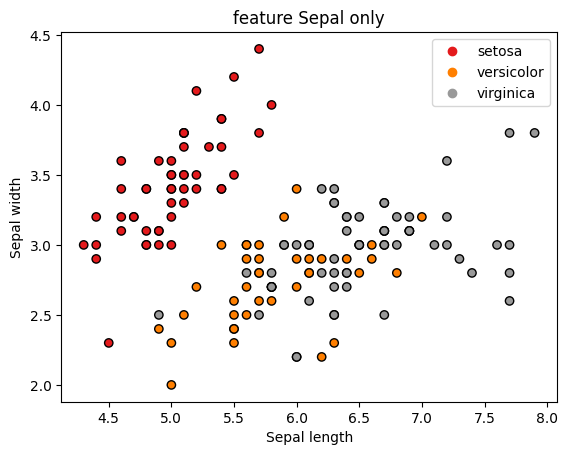

In [2]:

# just emdbedding by sepal features

X = iris.data[:, :2]  # we only take the first two features.
y = iris.target

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

fig, ax = plt.subplots()


# Plot the training points
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Set1, edgecolor="k")
ax.set_title("feature Sepal only")
ax.set_xlabel("Sepal length")
ax.set_ylabel("Sepal width")

classes = [iris.target_names[0],iris.target_names[1],iris.target_names[2]]
legend = ax.legend(*scatter.legend_elements())
plt.legend(handles=scatter.legend_elements()[0], labels=classes)
plt.show()

## 3. PCA 차원 축소 (선형)

**Principal Component Analysis** 는 데이터의 분산이 최대인 방향(주성분) 을 찾아 그 위에 데이터를 사영합니다. 4차원을 2차원으로 줄여 시각화하면 setosa 가 다른 두 클래스와 잘 분리되는 것을 확인할 수 있습니다.

| 방법 | 보존 대상 | 비선형 |
|---|---|---|
| Feature Selection | 선택한 원본 특성 | ✗ |
| PCA | 전체 분산 (선형) | ✗ |
| t-SNE | 국소 이웃 관계 | ✓ |
| UMAP | 국소 + 일부 전역 | ✓ |

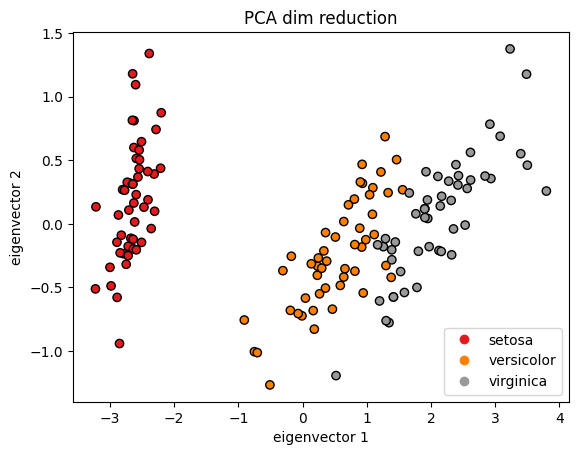

In [3]:

# To getter a better understanding of interaction of the dimensions
# plot the first two PCA dimensions

from sklearn.decomposition import PCA

X_reduced1 = PCA(n_components=2).fit_transform(iris.data)


x_min, x_max = X_reduced1[:, 0].min() - 0.5, X_reduced1[:, 0].max() + 0.5
y_min, y_max = X_reduced1[:, 1].min() - 0.5, X_reduced1[:, 1].max() + 0.5

fig, ax = plt.subplots()


# Plot the training points
scatter = ax.scatter(X_reduced1[:, 0], X_reduced1[:, 1], c=y, cmap=plt.cm.Set1, edgecolor="k")
plt.title("PCA dim reduction")
plt.xlabel("eigenvector 1")
plt.ylabel("eigenvector 2")

classes = [iris.target_names[0],iris.target_names[1],iris.target_names[2]]
legend = ax.legend(*scatter.legend_elements())
plt.legend(handles=scatter.legend_elements()[0], labels=classes)
plt.show()

## 4. SVD 차원 축소 (TruncatedSVD)

`TruncatedSVD` 는 PCA 와 비슷하지만 **평균 중심화를 하지 않습니다**. 그래서 희소 행렬(예: TF-IDF) 에 직접 적용 가능합니다. IRIS 처럼 밀집 데이터에서는 PCA 와 결과가 거의 같습니다.

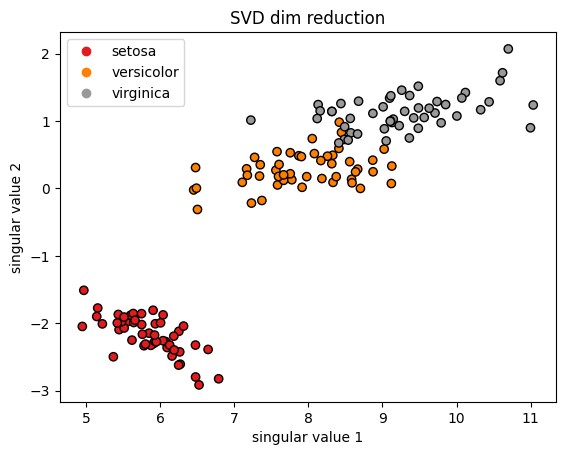

In [4]:
from sklearn.decomposition import TruncatedSVD


# To getter a better understanding of interaction of the dimensions
# plot the first two SVD sigular values

X_reduced2 = TruncatedSVD(n_components=2).fit_transform(iris.data)


x_min, x_max = X_reduced2[:, 0].min() - 0.5, X_reduced2[:, 0].max() + 0.5
y_min, y_max = X_reduced2[:, 1].min() - 0.5, X_reduced2[:, 1].max() + 0.5


fig, ax = plt.subplots()

# Plot the training points
scatter = ax.scatter(X_reduced2[:, 0], X_reduced2[:, 1], c=y, cmap=plt.cm.Set1, edgecolor="k")
plt.title("SVD dim reduction")
plt.xlabel("singular value 1")
plt.ylabel("singular value 2")

classes = [iris.target_names[0],iris.target_names[1],iris.target_names[2]]
legend = ax.legend(*scatter.legend_elements())
plt.legend(handles=scatter.legend_elements()[0], labels=classes)
plt.show()


## 5. t-SNE 차원 축소 (비선형)

**t-SNE** 는 고차원의 국소 이웃 관계가 저차원에서도 비슷하게 유지되도록 학습하는 비선형 임베딩 기법입니다. 시각화 품질은 매우 좋지만 다음을 주의해야 합니다.

- 거리/면적/축에 의미가 거의 없음 (시각적 군집만 봄)
- 매번 결과가 달라질 수 있음 (`random_state` 고정 권장)
- 새 데이터에 `transform` 불가 (학습 데이터 전용)

In [ ]:

# dimensionalty reduction by t-SNE
from sklearn.manifold import TSNE

X_reduced3 = TSNE(n_components=2, max_iter=50000).fit_transform(iris.data)


x_min, x_max = X_reduced3[:, 0].min() - 0.5, X_reduced3[:, 0].max() + 0.5
y_min, y_max = X_reduced3[:, 1].min() - 0.5, X_reduced3[:, 1].max() + 0.5


fig, ax = plt.subplots()

# Plot the training points
scatter = ax.scatter(X_reduced3[:, 0], X_reduced3[:, 1], c=y, cmap=plt.cm.Set1, edgecolor="k")
plt.title("t-SNE dim reduction")
plt.xlabel("x 1")
plt.ylabel("x 2")

classes = [iris.target_names[0],iris.target_names[1],iris.target_names[2]]
legend = ax.legend(*scatter.legend_elements())
plt.legend(handles=scatter.legend_elements()[0], labels=classes)
plt.show()


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

## 6. UMAP 차원 축소

**UMAP (Uniform Manifold Approximation and Projection)** 은 t-SNE 와 비슷한 비선형 임베딩이지만 **빠르고**, **전역(global) 구조도 일부 보존** 하며, 새 데이터 변환(`transform`)이 가능합니다. 큰 데이터에서 t-SNE 의 대안으로 자주 쓰입니다.

| 파라미터 | 의미 |
|---|---|
| `n_components` | 출력 차원 |
| `n_neighbors` | 국소 이웃의 크기 — 작을수록 국소 구조 강조 |
| `min_dist` | 임베딩 평면에서 점들 간 최소 거리 — 클수록 산개 |

In [ ]:
!pip3 install umap-learn

In [ ]:
from umap import umap_ as UMAP

In [ ]:
umap_2d = UMAP.UMAP(n_components=2, n_neighbors=5, min_dist=0.3,)

X_reduced4 = umap_2d.fit_transform(iris.data)

x_min, x_max = X_reduced4[:, 0].min() - 0.5, X_reduced4[:, 0].max() + 0.5
y_min, y_max = X_reduced4[:, 1].min() - 0.5, X_reduced4[:, 1].max() + 0.5


fig, ax = plt.subplots()

# Plot the training points
scatter = ax.scatter(X_reduced4[:, 0], X_reduced4[:, 1], c=y, cmap=plt.cm.Set1, edgecolor="k")
plt.title("UMAP dim reduction")
plt.xlabel("x 1")
plt.ylabel("x 2")

classes = [iris.target_names[0],iris.target_names[1],iris.target_names[2]]
legend = ax.legend(*scatter.legend_elements())
plt.legend(handles=scatter.legend_elements()[0], labels=classes)
plt.show()

## 7. 차원 축소 성능 검증 (정량 평가)

지금까지는 산점도를 **눈으로** 보며 "잘 분리됐다" 고 판단했습니다. 하지만 시각적 인상은 주관적이므로, 임베딩 품질을 **숫자로** 검증하는 두 가지 대표 지표를 사용합니다.

### ① Trustworthiness (이웃 보존도)

> 고차원 공간에서 가까웠던 점들이, 저차원 임베딩에서도 여전히 이웃으로 남아 있는가?

- 정의: 저차원에서 새로 끼어든(원래는 멀었던) 이웃들에 페널티를 주어 `0~1` 로 환산. **1에 가까울수록 좋음**.
- **레이블 `y` 가 필요 없는** 비지도 지표 — 구조 보존 자체를 측정합니다.
- `sklearn.manifold.trustworthiness(X_high, X_low, n_neighbors=k)`

### ② KNN 분류 정확도 (클래스 분리도)

> 축소된 공간에서 K-최근접이웃 분류기가 클래스를 얼마나 잘 맞히는가?

- 임베딩 공간에서 같은 클래스끼리 잘 뭉쳐 있으면 KNN 정확도가 높습니다.
- **레이블 `y` 를 사용하는** 지도 지표 — 5-겹 교차검증으로 과적합 없이 측정합니다.
- 단, t-SNE/UMAP 처럼 클래스 분리를 위해 설계된 비선형 기법은 KNN 정확도가 높게 나오기 쉽다는 점에 유의하세요.

> **읽는 법** — 두 지표가 모두 높으면 (예: UMAP) "구조도 보존하고 클래스도 잘 나눈" 좋은 임베딩입니다. Feature Selection 처럼 정보를 버린 방법은 두 지표 모두 낮게 나옵니다.

In [ ]:
# 차원 축소 결과의 품질을 정량적으로 검증
from sklearn.manifold import trustworthiness
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# 평가 대상 임베딩 모음 (비교 기준으로 원본 4D 도 포함)
embeddings = {
    "Original (4D)":     iris.data,   # 축소하지 않은 원본 (상한선 기준)
    "Feature Sel (2D)":  X,           # sepal 2개만 선택
    "PCA (2D)":          X_reduced1,
    "TruncatedSVD (2D)": X_reduced2,
    "t-SNE (2D)":        X_reduced3,
    "UMAP (2D)":         X_reduced4,
}

results = []
for name, emb in embeddings.items():
    # 1) Trustworthiness: 고차원에서 가까웠던 이웃이 저차원에서도 이웃으로 유지되는 정도 (0~1, 클수록 좋음)
    tw = trustworthiness(iris.data, emb, n_neighbors=5)

    # 2) KNN 5-겹 교차검증 정확도: 임베딩 공간에서 클래스가 얼마나 잘 분리되는지
    knn = KNeighborsClassifier(n_neighbors=5)
    acc = cross_val_score(knn, emb, y, cv=5).mean()

    results.append((name, tw, acc))

print(f"{'method':18s} {'trustworthiness':>16s} {'KNN CV acc':>12s}")
print("-" * 48)
for name, tw, acc in results:
    print(f"{name:18s} {tw:16.3f} {acc:12.3f}")

In [ ]:
# 두 지표를 막대그래프로 한눈에 비교
import numpy as np

names = [r[0] for r in results]
tws   = [r[1] for r in results]
accs  = [r[2] for r in results]

idx = np.arange(len(names))
w = 0.38

fig, ax = plt.subplots(figsize=(11, 4.5))
b1 = ax.bar(idx - w/2, tws,  w, label="Trustworthiness (이웃 보존도)")
b2 = ax.bar(idx + w/2, accs, w, label="KNN CV accuracy (클래스 분리도)")

ax.set_xticks(idx)
ax.set_xticklabels(names, rotation=20, ha="right")
ax.set_ylim(0, 1.08)
ax.set_ylabel("score (0~1)")
ax.set_title("Dimensionality Reduction Quality Metrics")
ax.legend(loc="lower right")

# 막대 위에 값 표기
for rect in list(b1) + list(b2):
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, h + 0.012, f"{h:.2f}",
            ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()